In [2]:
import pandas as pd
from astroquery.mast import Catalogs
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import numpy as np


          id      tmag       RAD      MASS    teff       lst   distance  \
2  290928016  11.71960  0.259087  0.230760  3214.0  0.006453  22.128401   
3  119886634  12.72290  0.233468  0.203193  3351.0  0.006192  33.204800   
4  137156909  12.72780  0.258977  0.230639  3385.0  0.007933  38.083199   
5  283410775   9.32681  0.312879  0.291364  3240.0  0.009719   9.101660   
6  415085843   9.39770  0.314055  0.292715  3397.0  0.011833  10.430900   

                  gaia  
2  3963458767789502336  
3  1195774527922150272  
4   559555456085598336  
5  1893189736896880640  
6  5715352842388433664  


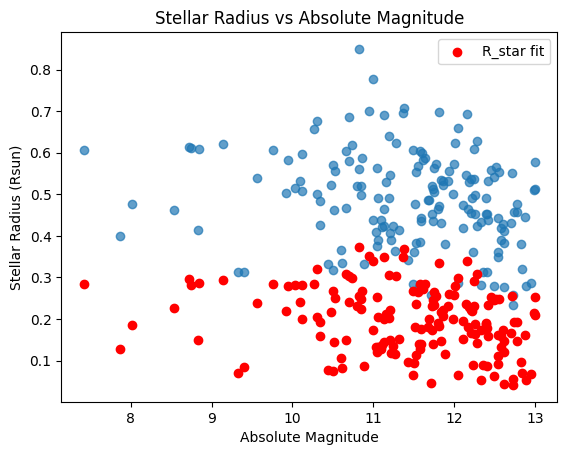

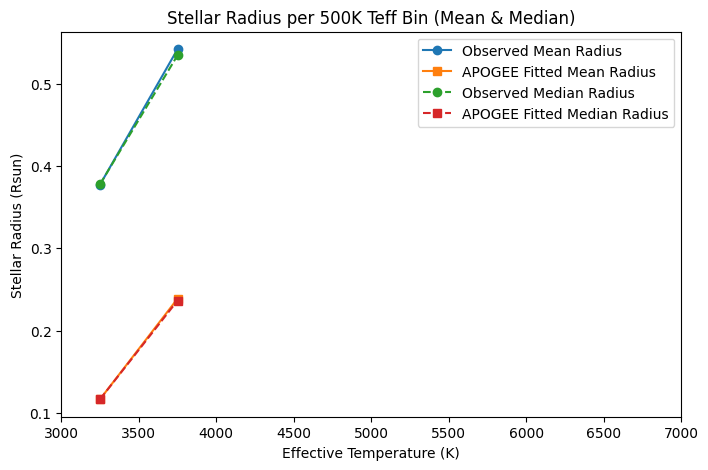

In [ ]:

CTLs = pd.read_csv("stellar_params_CTL.csv")
#CTLs = CTLs[CTLs['teff']< 4000]
print(CTLs.head())

plt.scatter(CTLs['tmag'], CTLs['RAD'], alpha=0.7)
plt.xlabel('Absolute Magnitude')
plt.ylabel('Stellar Radius (Rsun)')
plt.title('Stellar Radius vs Absolute Magnitude')

# Calculate R_star for each star in CTLs based on its tmag
CTLs['absolute_mag'] = CTLs['tmag'] - (5 * np.log10(CTLs['distance'] / 10)) # M=m-5log10​(d/10​)

CTLs['R_star_fit'] = 1.7420 - (0.2925 * CTLs['absolute_mag']) + (0.0123 * CTLs['absolute_mag']**2)
plt.scatter(CTLs['tmag'], CTLs['R_star_fit'], color='red', label='R_star fit')
plt.legend()
plt.show()

# Bin by effective temperature in 500K intervals
bins = np.arange(3000, 7001, 500)
CTLs['Teff_bin'] = pd.cut(CTLs['teff'], bins)

# Calculate mean and median stellar radius per bin for observed and fitted radii
mean_rad = CTLs.groupby('Teff_bin')['RAD'].mean()
mean_rad_fit = CTLs.groupby('Teff_bin')['R_star_fit'].mean()
median_rad = CTLs.groupby('Teff_bin')['RAD'].median()
median_rad_fit = CTLs.groupby('Teff_bin')['R_star_fit'].median()
bin_centers = [interval.mid for interval in mean_rad.index.categories]

plt.figure(figsize=(8,5))
plt.plot(bin_centers, mean_rad, marker='o', label='Observed Mean Radius')
plt.plot(bin_centers, mean_rad_fit, marker='s', label='APOGEE Fitted Mean Radius')
plt.plot(bin_centers, median_rad, marker='o', linestyle='--', label='Observed Median Radius')
plt.plot(bin_centers, median_rad_fit, marker='s', linestyle='--', label='APOGEE Fitted Median Radius')
plt.xlabel('Effective Temperature (K)')
plt.ylabel('Stellar Radius (Rsun)')
plt.title('Stellar Radius per 500K Teff Bin (Mean & Median)')
plt.legend()
plt.xlim(3000,7000)
plt.show()



Teff_bin
(3000, 3500]    0.341048
(3500, 4000]    0.538423
(4000, 4500]    0.702874
(4500, 5000]    0.776416
(5000, 5500]    0.894206
(5500, 6000]    1.066106
(6000, 6500]    1.359380
(6500, 7000]    1.706440
Name: st_rad, dtype: float64


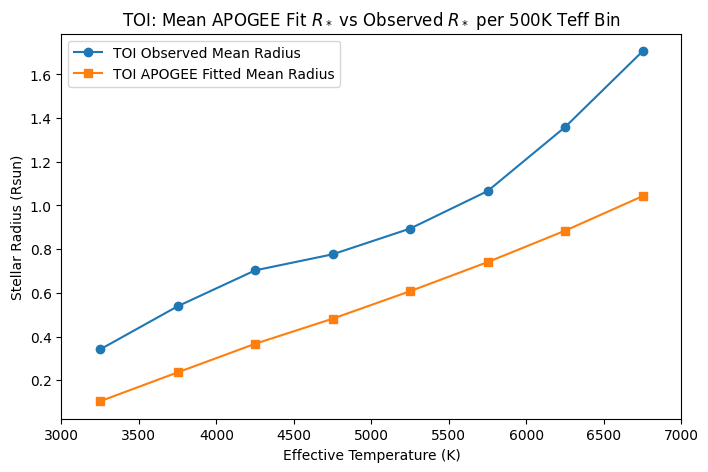

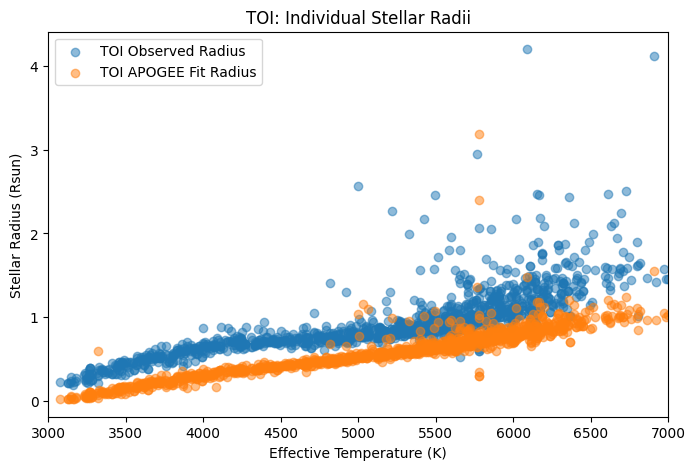

      R_p_apogee_fit   pl_rade
0           1.863288  3.300100
1           1.063835  1.525458
2           1.148200  1.622134
3           0.459833  2.076233
4           1.193226  1.694250
...              ...       ...
1219        1.280403  2.343228
1220        1.803950  2.777923
1221        1.857065  2.870220
1222        2.221282  3.207730
1223        2.187339  3.520250

[1224 rows x 2 columns]


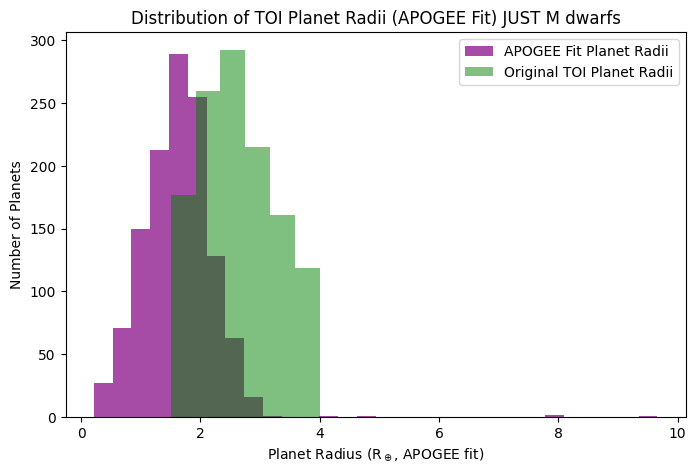

In [8]:
###TOIS

# Load the TOI catalog
toi = pd.read_csv("./TOI_Mar2025_1pt5to4_R_with_ruwe.csv")

# Calculate absolute magnitude for TOI stars (assuming 'tmag' and 'distance' columns exist)
toi['absolute_mag'] = toi['st_tmag'] - 5 * np.log10(toi['st_dist'] / 10)

# Calculate APOGEE fitted mean stellar radius using the same formula
toi['R_star_fit'] = 1.7420 - 0.2925 * toi['absolute_mag'] + 0.0123 * toi['absolute_mag']**2

# Bin by effective temperature in 500K intervals for TOI stars
toi['Teff_bin'] = pd.cut(toi['st_teff'], bins)

# Calculate mean observed and APOGEE fit stellar radius per bin
mean_rad_toi = toi.groupby('Teff_bin')['st_rad'].mean()
print(mean_rad_toi)
mean_rad_fit_toi = toi.groupby('Teff_bin')['R_star_apogee_fit'].mean()
bin_centers_toi = [interval.mid for interval in mean_rad_toi.index.categories]

plt.figure(figsize=(8,5))
plt.plot(bin_centers_toi, mean_rad_toi, marker='o', label='TOI Observed Mean Radius')
plt.plot(bin_centers_toi, mean_rad_fit_toi, marker='s', label='TOI APOGEE Fitted Mean Radius')
plt.xlabel('Effective Temperature (K)')
plt.ylabel('Stellar Radius (Rsun)')
plt.title('TOI: Mean APOGEE Fit $R_*$ vs Observed $R_*$ per 500K Teff Bin')
plt.legend()
plt.xlim(3000,7000)
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(toi['st_teff'], toi['st_rad'], alpha=0.5, label='TOI Observed Radius', color='tab:blue')
plt.scatter(toi['st_teff'], toi['R_star_apogee_fit'], alpha=0.5, label='TOI APOGEE Fit Radius', color='tab:orange')
plt.xlabel('Effective Temperature (K)')
plt.ylabel('Stellar Radius (Rsun)')
plt.title('TOI: Individual Stellar Radii')
plt.legend()
plt.xlim(3000, 7000)
plt.show()

# Calculate new planet radius using the same Rp/Rstar ratio but with the new fitted stellar radius
toi['R_p_sun_units_apogee_fit'] = (toi['pl_rade'] * 0.00916794 )/ toi['st_rad'] * toi['R_star_apogee_fit'] #mult by Rsun to Rearth conversion factor
toi['R_p_apogee_fit'] = toi['R_p_sun_units_apogee_fit'] / 0.00916794  # Convert back to Earth radii
#toi = toi[toi['st_teff'] >3000]
#toi = toi[toi['st_teff'] <4000]
print(toi[['R_p_apogee_fit', 'pl_rade']])

plt.figure(figsize=(8,5))
plt.hist(toi['R_p_apogee_fit'].dropna(), bins=30, color='purple', alpha=0.7, label='APOGEE Fit Planet Radii')
plt.hist(toi['pl_rade'].dropna(), bins=6, color='green', alpha=0.5, label='Original TOI Planet Radii')
plt.xlabel('Planet Radius (R$_\\oplus$, APOGEE fit)')
plt.ylabel('Number of Planets')
plt.title('Distribution of TOI Planet Radii (APOGEE Fit) JUST M dwarfs')
plt.legend()
plt.show()

# Save the updated TOI catalog
toi.to_csv("TOI_Mar2025_1pt5to4_R_with_ruwe.csv", index=False)

In [8]:
# USING H-BAND - ACCURATE VERSION

import pandas as pd
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import numpy as np
import matplotlib.pyplot as plt
# Load the injection-recovery results
twomass = pd.read_csv("./TESS13_jtayar_Tlt13.csv")
CTLs = pd.read_csv("stellar_params_CTL.csv")


# Cross-match CTLs with the injection-recovery results on TIC ID
ctl_matched = CTLs[CTLs['id'].isin(twomass['id'])]

# Add the TWOMASS column by merging with twomass dataframe
ctl_matched = ctl_matched.merge(twomass[['id', 'TWOMASS']], on='id', how='left')

print(f"Number of CTL stars matched: {len(ctl_matched)}")
print(f"CTL matched sample:\n{ctl_matched.head()}")

import astropy.units as u

# Initialize Vizier query for 2MASS catalog
Vizier.ROW_LIMIT = -1  # No row limit

# Initialize list to store H-band magnitudes
h_mags = []

# Query 2MASS for each star using TWOMASS ID coordinates
for idx, row in ctl_matched.iterrows():
    twomass_id = row['TWOMASS']
    
    # Skip if TWOMASS ID is missing
    if pd.isna(twomass_id):
        h_mags.append(np.nan)
        continue
    
    # Parse TWOMASS ID to extract coordinates (format: HHMMSS±DDMMSS)
    # Split on + or - to separate RA and Dec
    if '+' in twomass_id:
        ra_part, dec_part = twomass_id.split('+')
        dec_sign = '+'
    elif '-' in twomass_id:
        ra_part, dec_part = twomass_id.split('-')
        dec_sign = '-'
    else:
        h_mags.append(np.nan)
        continue
    
    # Format RA: HHMMSS -> HH:MM:SS
    ra_str = ra_part[:2] + ':' + ra_part[2:4] + ':' + ra_part[4:6]
    # Format Dec: DDMMSS -> ±DD:MM:SS
    dec_str = dec_sign + dec_part[:2] + ':' + dec_part[2:4] + ':' + dec_part[4:6]
    
    try:
        coord = SkyCoord(ra_str + ' ' + dec_str, unit=(u.hourangle, u.deg))
        
        # Query 2MASS catalog
        result = Vizier.query_region(coord, radius=2*u.arcsec, catalog='II/246/out')
        
        if len(result) > 0 and 'Hmag' in result[0].colnames:
            h_mag = result[0]['Hmag'][0]
            h_mags.append(h_mag)
        else:
            h_mags.append(np.nan)
    except:
        h_mags.append(np.nan)
    
    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1}/{len(ctl_matched)} stars")

# Add H-band magnitudes to ctl_matched
ctl_matched['h_mag'] = h_mags

print(f"\nH-band magnitudes retrieved: {ctl_matched['h_mag'].notna().sum()}/{len(ctl_matched)}")
print(ctl_matched[['id', 'TWOMASS', 'h_mag']].head())

Number of CTL stars matched: 1191
CTL matched sample:
          id     tmag       RAD      MASS     teff        lst    distance  \
0  158235404  11.2850  0.180000  0.470000  31000.0  26.957928  928.760990   
1   13145616  11.2870  0.180000  0.470000  29840.0  23.143818  498.267000   
2  290928016  11.7196  0.259087  0.230760   3214.0   0.006453   22.128401   
3  119886634  12.7229  0.233468  0.203193   3351.0   0.006192   33.204800   
4  137156909  12.7278  0.258977  0.230639   3385.0   0.007933   38.083199   

                  gaia           TWOMASS  
0  6644387872330929792  19094237-5344143  
1  2955576114040770304  05072015-2802247  
2  3963458767789502336  11130059+1025059  
3  1195774527922150272  15463417+1518431  
4   559555456085598336  02002351+7621462  
Processed 100/1191 stars
Processed 200/1191 stars
Processed 300/1191 stars
Processed 400/1191 stars
Processed 500/1191 stars
Processed 600/1191 stars
Processed 700/1191 stars
Processed 800/1191 stars
Processed 900/1191 stars


Number of CTL stars with H-band data: 248/1191


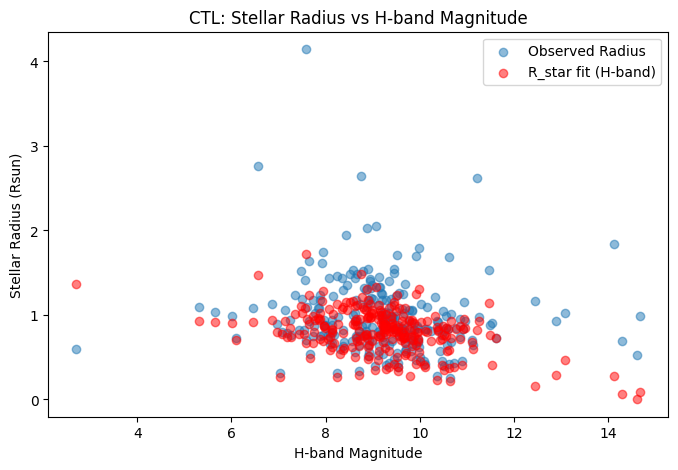

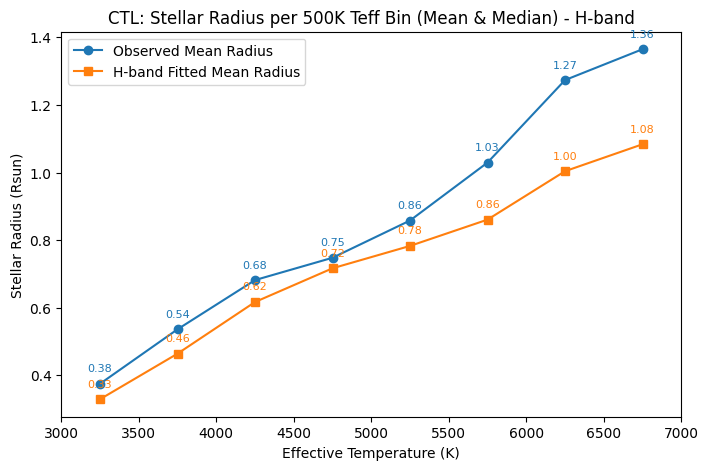

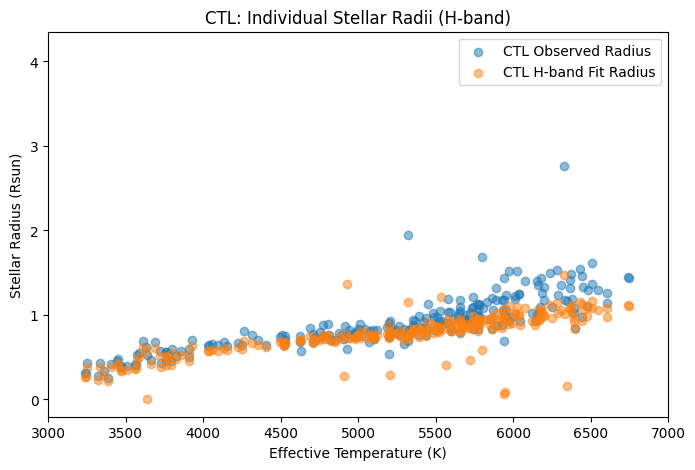


CTL Stellar Radius Statistics:
Original mean stellar radius: 0.975 R☉
H-band fit mean stellar radius: 0.804 R☉
Mean difference: -0.171 R☉
Median difference: -0.078 R☉

Saved updated CTL catalog with H-band data to: stellar_params_CTL_with_hband.csv


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
### CTL H-BAND ANALYSIS (from earlier cell - processed version)

# Use the already matched and processed CTL data from the earlier cell
# Filter for stars with valid h_mag data
ctl_hband_valid = ctl_matched[ctl_matched['h_mag'].notna()].copy()

print(f"Number of CTL stars with H-band data: {len(ctl_hband_valid)}/{len(ctl_matched)}")

# Calculate absolute H-band magnitude for each star
ctl_hband_valid['absolute_h_mag'] = ctl_hband_valid['h_mag'] - (5 * np.log10(ctl_hband_valid['distance'] / 10))

# Calculate R_star fit using H-band absolute magnitude (using Wanderley coefficients)
ctl_hband_valid['R_star_fit_h'] = 1.7420 - (0.2925 * ctl_hband_valid['absolute_h_mag']) + (0.0123 * ctl_hband_valid['absolute_h_mag']**2)

# Plot R_star fit vs h_mag
plt.figure(figsize=(8,5))
plt.scatter(ctl_hband_valid['h_mag'], ctl_hband_valid['RAD'], alpha=0.5, label='Observed Radius', color='tab:blue')
plt.scatter(ctl_hband_valid['h_mag'], ctl_hband_valid['R_star_fit_h'], color='red', alpha=0.5, label='R_star fit (H-band)')
plt.xlabel('H-band Magnitude')
plt.ylabel('Stellar Radius (Rsun)')
plt.title('CTL: Stellar Radius vs H-band Magnitude')
plt.legend()
plt.show()

# Bin by effective temperature in 500K intervals
bins = np.arange(3000, 7001, 500)
ctl_hband_valid['Teff_bin'] = pd.cut(ctl_hband_valid['teff'], bins)

# Calculate mean and median stellar radius per bin for observed and H-band fitted radii
mean_rad_ctl_h = ctl_hband_valid.groupby('Teff_bin')['RAD'].mean()
mean_rad_fit_ctl_h = ctl_hband_valid.groupby('Teff_bin')['R_star_fit_h'].mean()
median_rad_ctl_h = ctl_hband_valid.groupby('Teff_bin')['RAD'].median()
median_rad_fit_ctl_h = ctl_hband_valid.groupby('Teff_bin')['R_star_fit_h'].median()
bin_centers_ctl_h = [interval.mid for interval in mean_rad_ctl_h.index.categories]

plt.figure(figsize=(8,5))
plt.plot(bin_centers_ctl_h, mean_rad_ctl_h, marker='o', label='Observed Mean Radius', color='tab:blue')
plt.plot(bin_centers_ctl_h, mean_rad_fit_ctl_h, marker='s', label='H-band Fitted Mean Radius', color='tab:orange')
#plt.plot(bin_centers_ctl_h, median_rad_ctl_h, marker='o', linestyle='--', label='Observed Median Radius', color='tab:green')
#plt.plot(bin_centers_ctl_h, median_rad_fit_ctl_h, marker='s', linestyle='--', label='H-band Fitted Median Radius', color='tab:red')

# Annotate mean and median values for each bin
for x, y in zip(bin_centers_ctl_h, mean_rad_ctl_h):
    plt.text(x, y + 0.03, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='tab:blue')

for x, y in zip(bin_centers_ctl_h, mean_rad_fit_ctl_h):
    plt.text(x, y + 0.03, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='tab:orange')

#for x, y in zip(bin_centers_ctl_h, median_rad_ctl_h):
    #plt.text(x, y - 0.04, f"{y:.2f}", ha='center', va='top', fontsize=8, color='tab:green')

#for x, y in zip(bin_centers_ctl_h, median_rad_fit_ctl_h):
    #plt.text(x, y - 0.04, f"{y:.2f}", ha='center', va='top', fontsize=8, color='tab:red')

plt.xlabel('Effective Temperature (K)')
plt.ylabel('Stellar Radius (Rsun)')
plt.title('CTL: Stellar Radius per 500K Teff Bin (Mean & Median) - H-band')
plt.legend()
plt.xlim(3000, 7000)
plt.show()

# Scatter plot of individual stellar radii
plt.figure(figsize=(8,5))
plt.scatter(ctl_hband_valid['teff'], ctl_hband_valid['RAD'], alpha=0.5, label='CTL Observed Radius', color='tab:blue')
plt.scatter(ctl_hband_valid['teff'], ctl_hband_valid['R_star_fit_h'], alpha=0.5, label='CTL H-band Fit Radius', color='tab:orange')
plt.xlabel('Effective Temperature (K)')
plt.ylabel('Stellar Radius (Rsun)')
plt.title('CTL: Individual Stellar Radii (H-band)')
plt.legend()
plt.xlim(3000, 7000)
plt.show()

# Calculate statistics
print(f"\nCTL Stellar Radius Statistics:")
print(f"Original mean stellar radius: {ctl_hband_valid['RAD'].mean():.3f} R☉")
print(f"H-band fit mean stellar radius: {ctl_hband_valid['R_star_fit_h'].mean():.3f} R☉")
print(f"Mean difference: {(ctl_hband_valid['R_star_fit_h'] - ctl_hband_valid['RAD']).mean():.3f} R☉")
print(f"Median difference: {(ctl_hband_valid['R_star_fit_h'] - ctl_hband_valid['RAD']).median():.3f} R☉")

# Save the updated CTL catalog with H-band data
ctl_matched.to_csv("stellar_params_CTL_with_hband.csv", index=False)
print("\nSaved updated CTL catalog with H-band data to: stellar_params_CTL_with_hband.csv")

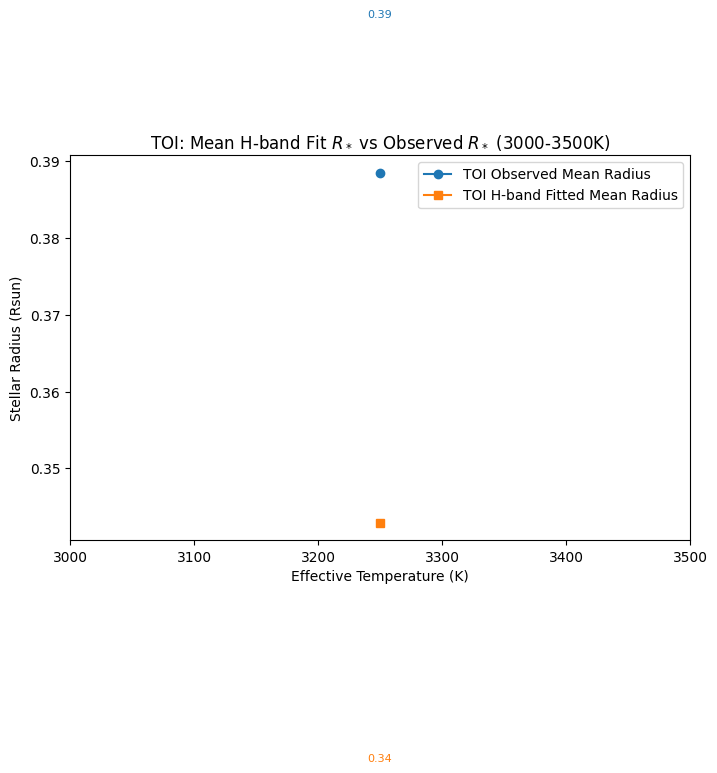

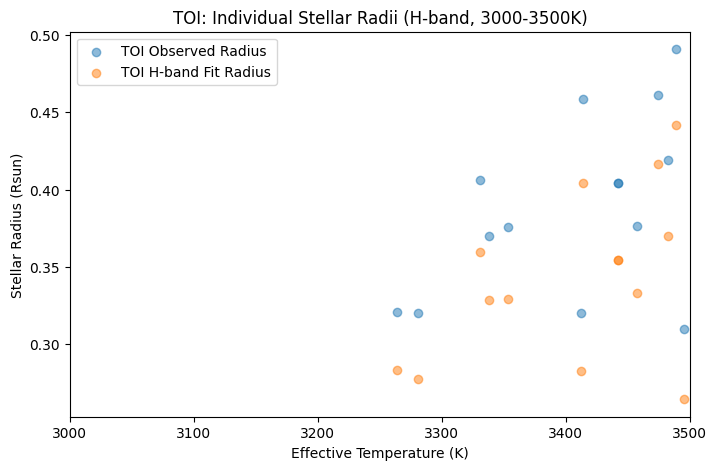

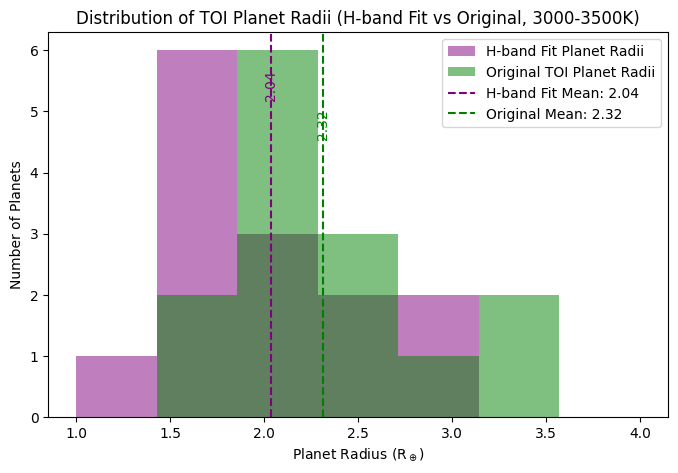


[3000-3500K] Original mean planet radius: 2.315 R⊕
[3000-3500K] H-band fit mean planet radius: 2.038 R⊕
[3000-3500K] Mean difference: -0.277 R⊕
[3000-3500K] Median difference: -0.269 R⊕


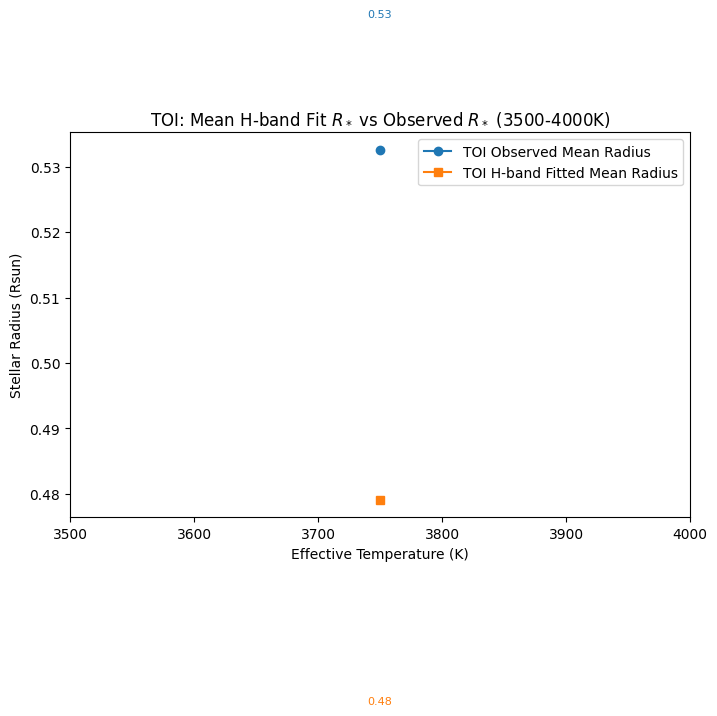

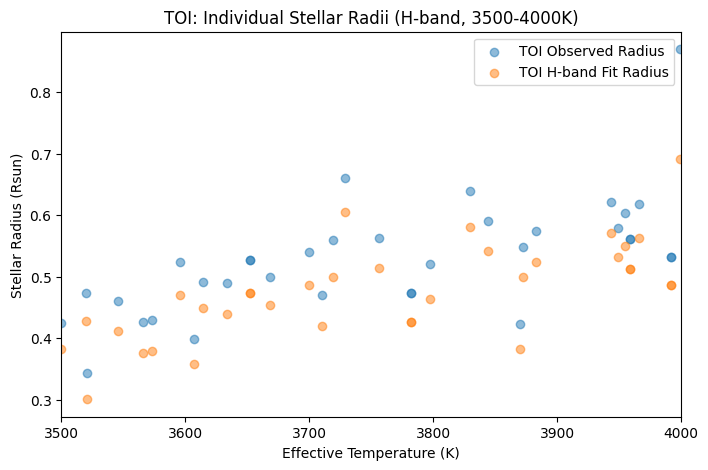

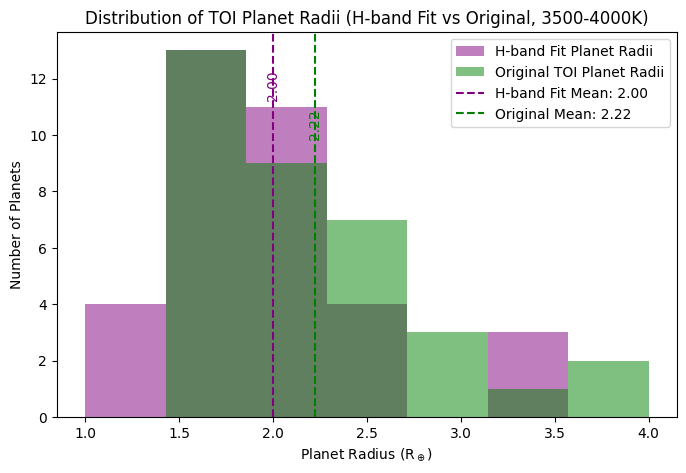


[3500-4000K] Original mean planet radius: 2.222 R⊕
[3500-4000K] H-band fit mean planet radius: 2.001 R⊕
[3500-4000K] Mean difference: -0.221 R⊕
[3500-4000K] Median difference: -0.196 R⊕


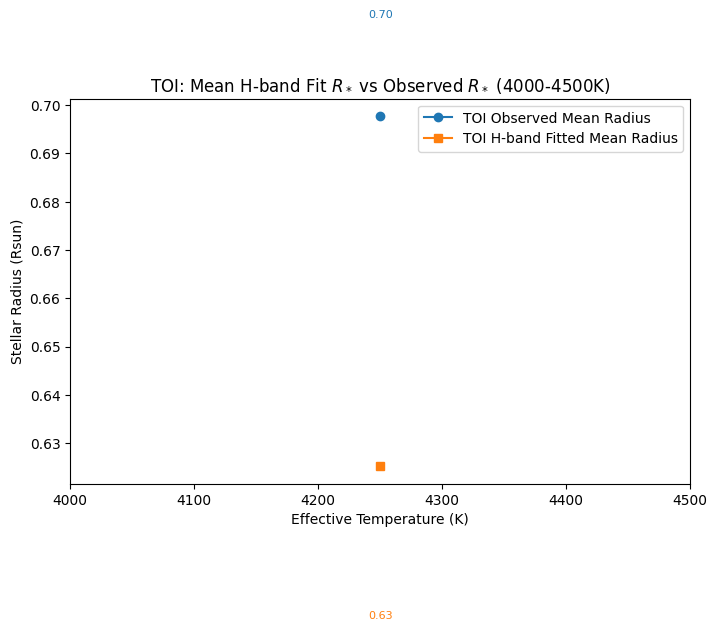

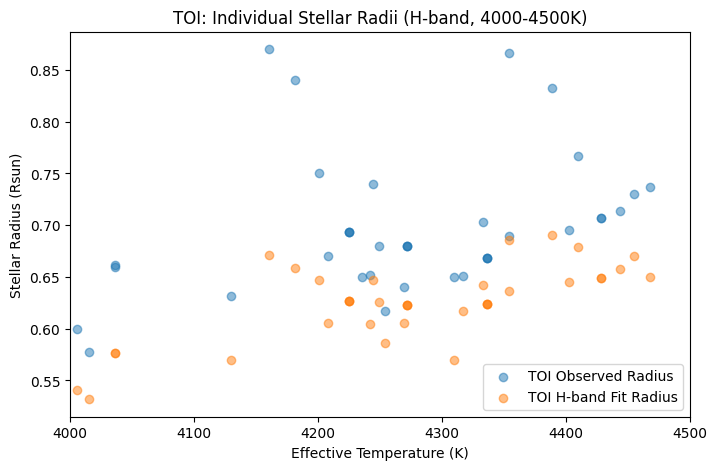

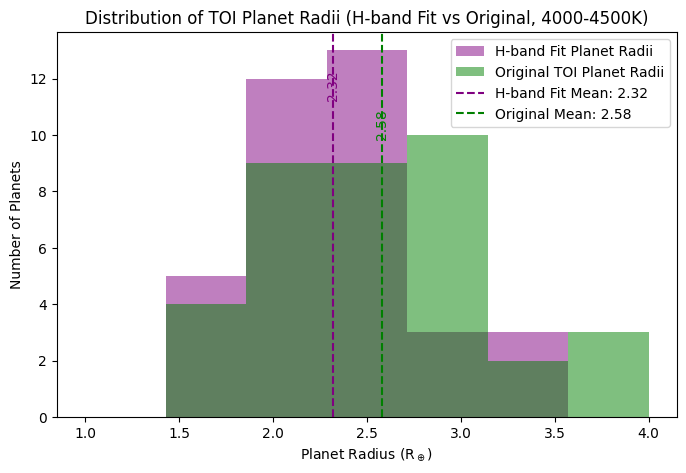


[4000-4500K] Original mean planet radius: 2.583 R⊕
[4000-4500K] H-band fit mean planet radius: 2.320 R⊕
[4000-4500K] Mean difference: -0.275 R⊕
[4000-4500K] Median difference: -0.228 R⊕


In [7]:
def toi_hband_analysis(teff_min, teff_max, toi_catalog="./TOI_Mar2025_1pt5to4_R_with_ruwe.csv", twomass_catalog="./TESS13_jtayar_Tlt13.csv"):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # Load catalogs
    toi_hband = pd.read_csv(toi_catalog)
    twomass = pd.read_csv(twomass_catalog)

    # Cross-match TIC IDs
    toi_hband['TIC_clean'] = toi_hband['id'].astype(str)
    twomass['TIC_clean'] = twomass['id'].astype(str)

    # Filter by Teff
    toi_hband = toi_hband[(toi_hband['st_teff'] < teff_max) & (toi_hband['st_teff'] >= teff_min)]

    # Merge to get TWOMASS IDs
    toi_matched = toi_hband.merge(twomass[['TIC_clean', 'TWOMASS']], 
                                  left_on='TIC_clean', 
                                  right_on='TIC_clean', 
                                  how='left')

    # Query H-band if needed
    if 'h_mag' not in toi_matched.columns:
        from astroquery.vizier import Vizier
        from astropy.coordinates import SkyCoord
        import astropy.units as u
        Vizier.ROW_LIMIT = -1
        h_mags_toi = []
        for idx, row in toi_matched.iterrows():
            twomass_id = row['TWOMASS']
            if pd.isna(twomass_id):
                h_mags_toi.append(np.nan)
                continue
            if '+' in twomass_id:
                ra_part, dec_part = twomass_id.split('+')
                dec_sign = '+'
            elif '-' in twomass_id:
                ra_part, dec_part = twomass_id.split('-')
                dec_sign = '-'
            else:
                h_mags_toi.append(np.nan)
                continue
            ra_str = ra_part[:2] + ':' + ra_part[2:4] + ':' + ra_part[4:6]
            dec_str = dec_sign + dec_part[:2] + ':' + dec_part[2:4] + ':' + dec_part[4:6]
            try:
                coord = SkyCoord(ra_str + ' ' + dec_str, unit=(u.hourangle, u.deg))
                result = Vizier.query_region(coord, radius=2*u.arcsec, catalog='II/246/out')
                if len(result) > 0 and 'Hmag' in result[0].colnames:
                    h_mag = result[0]['Hmag'][0]
                    h_mags_toi.append(h_mag)
                else:
                    h_mags_toi.append(np.nan)
            except:
                h_mags_toi.append(np.nan)
        toi_matched['h_mag'] = h_mags_toi

    # Filter for valid H-band data
    toi_hband_valid = toi_matched[toi_matched['h_mag'].notna()].copy()

    # Calculate absolute H-band magnitude
    toi_hband_valid['absolute_h_mag'] = toi_hband_valid['h_mag'] - 5 * np.log10(toi_hband_valid['st_dist'] / 10)

    # H-band fitted stellar radius
    toi_hband_valid['R_star_fit_h'] = 1.7420 - 0.2925 * toi_hband_valid['absolute_h_mag'] + 0.0123 * toi_hband_valid['absolute_h_mag']**2

    # Bin by effective temperature in 500K intervals
    bins = np.arange(teff_min, teff_max+1, 500)
    toi_hband_valid['Teff_bin'] = pd.cut(toi_hband_valid['st_teff'], bins)

    # Mean observed and H-band fit stellar radius per bin
    mean_rad_toi_h = toi_hband_valid.groupby('Teff_bin')['st_rad'].mean()
    mean_rad_fit_toi_h = toi_hband_valid.groupby('Teff_bin')['R_star_fit_h'].mean()
    bin_centers_toi_h = [interval.mid for interval in mean_rad_toi_h.index.categories]

    plt.figure(figsize=(8,5))
    plt.plot(bin_centers_toi_h, mean_rad_toi_h, marker='o', label='TOI Observed Mean Radius', color='tab:blue')
    plt.plot(bin_centers_toi_h, mean_rad_fit_toi_h, marker='s', label='TOI H-band Fitted Mean Radius', color='tab:orange')
    for x, y in zip(bin_centers_toi_h, mean_rad_toi_h):
        plt.text(x, y + 0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=8, color='tab:blue')
    for x, y in zip(bin_centers_toi_h, mean_rad_fit_toi_h):
        plt.text(x, y - 0.03, f"{y:.2f}", ha='center', va='top', fontsize=8, color='tab:orange')
    plt.xlabel('Effective Temperature (K)')
    plt.ylabel('Stellar Radius (Rsun)')
    plt.title(f'TOI: Mean H-band Fit $R_*$ vs Observed $R_*$ ({teff_min}-{teff_max}K)')
    plt.legend()
    plt.xlim(teff_min, teff_max)
    plt.show()

    # Scatter plot of individual stellar radii
    plt.figure(figsize=(8,5))
    plt.scatter(toi_hband_valid['st_teff'], toi_hband_valid['st_rad'], alpha=0.5, label='TOI Observed Radius', color='tab:blue')
    plt.scatter(toi_hband_valid['st_teff'], toi_hband_valid['R_star_fit_h'], alpha=0.5, label='TOI H-band Fit Radius', color='tab:orange')
    plt.xlabel('Effective Temperature (K)')
    plt.ylabel('Stellar Radius (Rsun)')
    plt.title(f'TOI: Individual Stellar Radii (H-band, {teff_min}-{teff_max}K)')
    plt.legend()
    plt.xlim(teff_min, teff_max)
    plt.show()

    # Calculate new planet radius using H-band fitted stellar radius
    toi_hband_valid['R_p_sun_units_h_fit'] = (toi_hband_valid['pl_rade'] * 0.00916794) / toi_hband_valid['st_rad'] * toi_hband_valid['R_star_fit_h']
    toi_hband_valid['R_p_h_fit'] = toi_hband_valid['R_p_sun_units_h_fit'] / 0.00916794

    # Set bins for planet radius histogram: 6 bins from 1.5 to 4
    radius_bins = np.linspace(1, 4, 8)
    # Plot histogram of planet radii
    plt.figure(figsize=(8,5))
    n1, bins1, _ = plt.hist(toi_hband_valid['R_p_h_fit'].dropna(), bins=radius_bins, color='purple', alpha=0.5, label='H-band Fit Planet Radii')
    n2, bins2, _ = plt.hist(toi_hband_valid['pl_rade'].dropna(), bins=radius_bins, color='green', alpha=0.5, label='Original TOI Planet Radii')

    # Plot mean planet radii as vertical lines
    mean_rp_h_fit = toi_hband_valid['R_p_h_fit'].mean()
    mean_rp_orig = toi_hband_valid['pl_rade'].mean()
    plt.axvline(mean_rp_h_fit, color='purple', linestyle='--', label=f'H-band Fit Mean: {mean_rp_h_fit:.2f}')
    plt.axvline(mean_rp_orig, color='green', linestyle='--', label=f'Original Mean: {mean_rp_orig:.2f}')
    plt.text(mean_rp_h_fit, plt.ylim()[1]*0.9, f"{mean_rp_h_fit:.2f}", color='purple', ha='center', va='top', fontsize=10, rotation=90)
    plt.text(mean_rp_orig, plt.ylim()[1]*0.8, f"{mean_rp_orig:.2f}", color='green', ha='center', va='top', fontsize=10, rotation=90)

    plt.xlabel('Planet Radius (R$_\\oplus$)')
    plt.ylabel('Number of Planets')
    plt.title(f'Distribution of TOI Planet Radii (H-band Fit vs Original, {teff_min}-{teff_max}K)')
    plt.legend()
    plt.show()

    # Statistics
    print(f"\n[{teff_min}-{teff_max}K] Original mean planet radius: {mean_rp_orig:.3f} R⊕")
    print(f"[{teff_min}-{teff_max}K] H-band fit mean planet radius: {mean_rp_h_fit:.3f} R⊕")
    print(f"[{teff_min}-{teff_max}K] Mean difference: {(toi_hband_valid['R_p_h_fit'] - toi_hband_valid['pl_rade']).mean():.3f} R⊕")
    print(f"[{teff_min}-{teff_max}K] Median difference: {(toi_hband_valid['R_p_h_fit'] - toi_hband_valid['pl_rade']).median():.3f} R⊕")

    return toi_hband_valid

# Run for each temperature range
toi_hband_3000_3500 = toi_hband_analysis(3000, 3500)
toi_hband_3500_4000 = toi_hband_analysis(3500, 4000)
toi_hband_4000_4500 = toi_hband_analysis(4000, 4500)
